# NSO data exploration & crop Marker Wadden area

## Import data (single tif)

In [1]:
tif_file_name = "data/NSO/20241026_105131_Se2_10m_8bit_MOS_RGB_RD_Nederland/20241026_105131_Se2_10m_8bit_MOS_RGB_RD_Nederland.tif"

Read with rasterio — shape (bands, rows, cols): (3, 31781, 27223) dtype: uint8


MemoryError: Unable to allocate 2.42 GiB for an array with shape (31781, 27223, 3) and data type bool

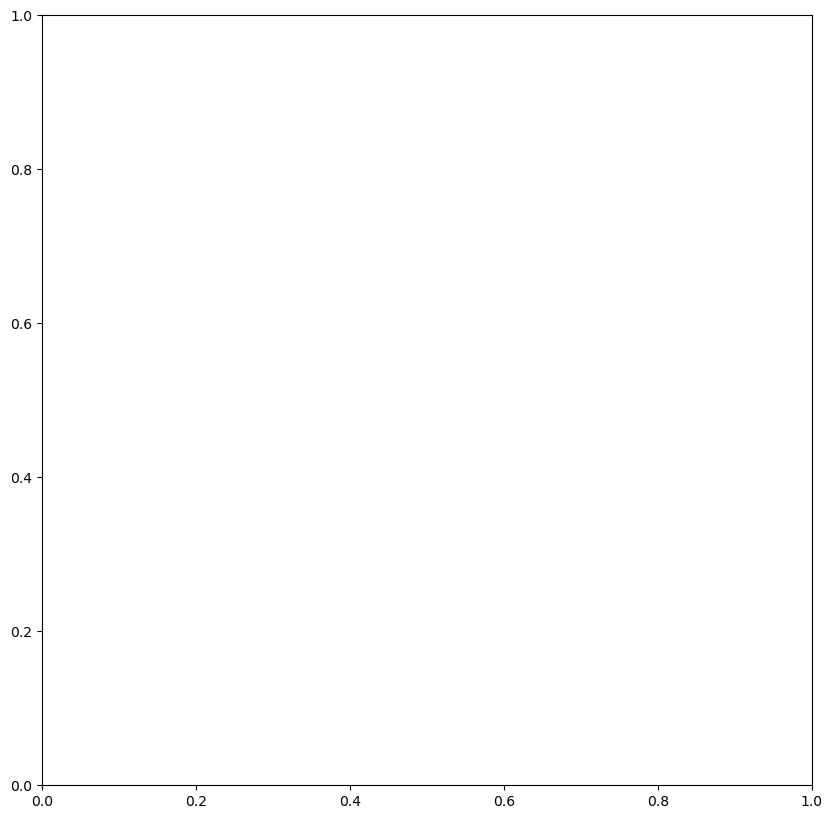

In [2]:
import numpy as np
import rasterio
from rasterio.plot import reshape_as_image
import tifffile

import matplotlib.pyplot as plt

# try rasterio first (keeps geospatial metadata), fall back to tifffile
try:

    with rasterio.open(tif_file_name) as src:
        data = src.read()             # shape: (bands, rows, cols)
        profile = src.profile
    print("Read with rasterio — shape (bands, rows, cols):", data.shape, "dtype:", data.dtype)
    # reshape for display: (rows, cols, bands)
    if data.ndim == 3:
        img = reshape_as_image(data)
    else:
        img = data
except Exception:
    data = tifffile.imread(tif_file_name)
    print("Read with tifffile — shape:", data.shape, "dtype:", data.dtype)
    # if data is (bands, rows, cols) convert to (rows, cols, bands)
    if data.ndim == 3 and data.shape[0] in (1, 3, 4):
        img = np.moveaxis(data, 0, -1)
    else:
        img = data

# Display
plt.figure(figsize=(10, 10))
if img.ndim == 3 and img.shape[2] in (3, 4):
    plt.imshow(img)
else:
    plt.imshow(img if img.ndim == 2 else img[:, :, 0], cmap="gray")
plt.axis("off")
plt.show()

these are the rough coordinates of the Marker Wadden area
* 52.608140, 5.348070
* 52.609043, 5.411442
* 52.562648, 5.423134
* 52.559665, 5.349949

I want to crop the image to this area.
how ever please make the numbers simpler by finding the min, max of lat lon from these 4 coordinates to make regular rectangle


In [12]:
markerwarden_min_lat = 52.56
markerwarden_max_lat = 52.61
markerwarden_min_lon = 5.34
markerwarden_max_lon = 5.43

In [13]:
# Crop to Marker Wadden area (approximate coordinates)
# Coordinates in EPSG:28992 (Amersfoort / RD New)
from pyproj import Transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
min_x, min_y = transformer.transform(markerwarden_min_lon, markerwarden_min_lat)
max_x, max_y = transformer.transform(markerwarden_max_lon, markerwarden_max_lat)
print(f"Marker Wadden area in EPSG:28992: min_x={min_x}, min_y={min_y}, max_x={max_x}, max_y={max_y}")
from rasterio.windows import from_bounds
with rasterio.open(tif_file_name) as src:
    window = from_bounds(min_x, min_y, max_x, max_y, src.transform)
    cropped_data = src.read(window=window)
    cropped_img = reshape_as_image(cropped_data)
    cropped_profile = src.profile
    cropped_profile.update({"height": cropped_data.shape[1],
                            "width": cropped_data.shape[2],
                            "transform": src.transform})
print("Cropped shape (bands, rows, cols):", cropped_data.shape)

Marker Wadden area in EPSG:28992: min_x=151798.90904974975, min_y=508044.0481947349, max_x=157898.73194348364, max_y=513607.37776137027
Cropped shape (bands, rows, cols): (3, 556, 610)


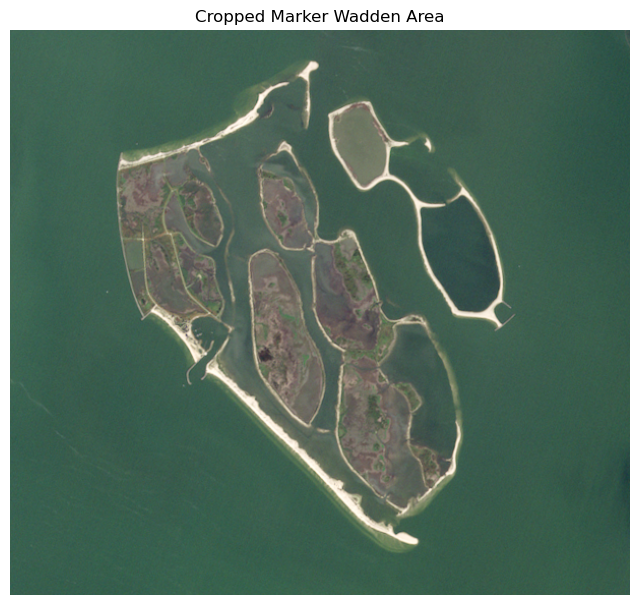

In [14]:
# visualize cropped area
plt.figure(figsize=(8, 8))
if cropped_img.ndim == 3 and cropped_img.shape[2] in (3, 4):
    plt.imshow(cropped_img)
else:
    plt.imshow(cropped_img if cropped_img.ndim == 2 else cropped_img[:, :, 0], cmap="gray")
plt.axis("off")
plt.title("Cropped Marker Wadden Area")
plt.show()

In [17]:
# print info about cropped image
height = cropped_profile.get("height", cropped_data.shape[1])
width = cropped_profile.get("width", cropped_data.shape[2])
bands = cropped_profile.get("count", cropped_data.shape[0])
dtype = cropped_profile.get("dtype", cropped_data.dtype)
transform = cropped_profile.get("transform", None)
crs = cropped_profile.get("crs", None)
nodata = cropped_profile.get("nodata", None)

pixel_size_x = transform.a if transform is not None else None
pixel_size_y = -transform.e if transform is not None else None

print("Cropped image summary")
print("---------------------")
print(f"Width x Height : {width} x {height} pixels")
print(f"Bands          : {bands}")
print(f"Dtype          : {dtype}")
print(f"NoData value   : {nodata}")
print(f"Array shape (bands, rows, cols): {cropped_data.shape}")
print(f"Display shape (rows, cols, bands) : {cropped_img.shape}")
print(f"CRS            : {crs}")
print(f"Transform      : {transform}")
print(f"Pixel size     : {pixel_size_x} m x {pixel_size_y} m")
# bounding box in EPSG:28992 (if min/max are available)
if all(v is not None for v in (min_x, min_y, max_x, max_y)):
    print(f"Bounds (EPSG:28992) : left={min_x:.3f}, bottom={min_y:.3f}, right={max_x:.3f}, top={max_y:.3f}")
# window used to read the crop (if available)
if "window" in globals():
    print(f"Read window     : {window}")

Cropped image summary
---------------------
Width x Height : 610 x 556 pixels
Bands          : 3
Dtype          : uint8
NoData value   : 0.0
Array shape (bands, rows, cols): (3, 556, 610)
Display shape (rows, cols, bands) : (556, 610, 3)
CRS            : EPSG:28992
Transform      : | 10.00, 0.00, 7628.76|
| 0.00,-10.00, 624657.43|
| 0.00, 0.00, 1.00|
Pixel size     : 10.0 m x 10.0 m
Bounds (EPSG:28992) : left=151798.909, bottom=508044.048, right=157898.732, top=513607.378
Read window     : Window(col_off=14417.015294966603, row_off=11105.004764551086, width=609.982289373389, height=556.3329566635366)
